# Session - 11 Classification Algorithms Part - 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Task 1.
Implement a K-Nearest Neighbors (KNN) classifier in Python to predict whether a Flipkart product review is 'positive' or 'negative' using a small dataset of review texts and their labels.<br><br><em><strong>Hint:</strong> Use scikit-learn's KNeighborsClassifier and convert the text data into numerical features using CountVectorizer.</em>

In [7]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import KNeighborsClassifier

In [8]:
reviews = [
    "Good product",
    "Nice product",
    "Great product",
    "Bad item",
    "Defective item",
    "Worst item"
]
labels = ['positive', 'positive', 'positive', 'negative', 'negative', 'negative']

In [9]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(reviews)

knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X, labels)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [10]:
test_review = ["Bad item"]
X_test = vectorizer.transform(test_review)
prediction = knn_model.predict(X_test)

print(f"Review: '{test_review[0]}'")
print(f"Prediction: {prediction[0]}")

Review: 'Bad item'
Prediction: negative


---

# Task 2.
Compare the accuracy of KNN using Euclidean distance vs. Manhattan distance on a dataset of Spotify song features (e.g., tempo, danceability, energy) to classify songs as 'workout' or 'chill' playlists.<br><br><em><strong>Hint:</strong> Use the 'metric' parameter in KNeighborsClassifier to switch between 'euclidean' and 'manhattan'.</em>

In [11]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [24]:
# [tempo, danceability, energy]
spotify_features = np.array([
    [140, 0.8, 0.9], [135, 0.7, 0.85], [150, 0.9, 0.95], [128, 0.75, 0.8],
    [80, 0.4, 0.3], [75, 0.3, 0.2], [90, 0.5, 0.4], [85, 0.45, 0.35],
    [145, 0.85, 0.88], [130, 0.72, 0.82], [70, 0.2, 0.15], [82, 0.38, 0.25]
])
spotify_labels = ['workout', 'workout', 'workout', 'workout', 
                    'chill', 'chill', 'chill', 'chill',
                    'workout', 'workout', 'chill', 'chill']

X_train_sp, X_test_sp, y_train_sp, y_test_sp = train_test_split(
    spotify_features, spotify_labels, test_size=0.3, random_state=42
)

In [25]:
X_train_sp

array([[ 75.  ,   0.3 ,   0.2 ],
       [150.  ,   0.9 ,   0.95],
       [135.  ,   0.7 ,   0.85],
       [ 82.  ,   0.38,   0.25],
       [ 80.  ,   0.4 ,   0.3 ],
       [ 85.  ,   0.45,   0.35],
       [128.  ,   0.75,   0.8 ],
       [ 90.  ,   0.5 ,   0.4 ]])

In [26]:
knn_euclidean = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn_euclidean.fit(X_train_sp, y_train_sp)
preds_euclidean = knn_euclidean.predict(X_test_sp)
acc_euclidean = accuracy_score(y_test_sp, preds_euclidean)

In [27]:
knn_manhattan = KNeighborsClassifier(n_neighbors=3, metric='manhattan')
knn_manhattan.fit(X_train_sp, y_train_sp)
preds_manhattan = knn_manhattan.predict(X_test_sp)
acc_manhattan = accuracy_score(y_test_sp, preds_manhattan)

In [28]:
print(f"Accuracy with Euclidean distance: {acc_euclidean}")
print(f"Accuracy with Manhattan distance: {acc_manhattan}")

Accuracy with Euclidean distance: 1.0
Accuracy with Manhattan distance: 1.0


**Explanation:**   
Both distances provide high accuracy for this cleanly separated dummy dataset. The **Euclidean distance** calculates the shortest straight-line path between two points, while the **Manhattan distance** calculates the sum of absolute differences across all dimensions. For high-dimensional sparse data, Manhattan can sometimes perform better, but for basic physical or small-dimensional features, Euclidean is a great default.

---

# Task 3.
Use Gaussian Naive Bayes to classify whether an IRCTC train booking is likely to be 'confirmed' or 'waitlisted' based on features like booking time, train popularity, and travel day (use a small mock dataset).

In [29]:
from sklearn.naive_bayes import GaussianNB

In [30]:
#[Days_in_advance, Train_popularity (1-10), Travel_day_of_week (0-6)]
irctc_features = np.array([
    [60, 5, 2], [50, 4, 3], [120, 8, 1], [90, 7, 2],
    [2, 9, 5], [1, 10, 6], [5, 8, 4], [10, 9, 5],
    [30, 3, 0], [45, 6, 1],
    [3, 8, 5], [7, 7, 6]
])
irctc_labels = ['confirmed', 'confirmed', 'confirmed', 'confirmed',
                'waitlisted', 'waitlisted', 'waitlisted', 'waitlisted',
                'confirmed', 'confirmed',
                'waitlisted', 'waitlisted']

In [31]:
gnb_model = GaussianNB()
gnb_model.fit(irctc_features, irctc_labels)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [33]:
new_booking = np.array([[4, 9, 5]])
gnb_pred = gnb_model.predict(new_booking)

print(f"New Booking Features: {new_booking}")
print(f"Prediction: {gnb_pred[0]}")

New Booking Features: [[4 9 5]]
Prediction: waitlisted


---

# Task 4.
Build a Multinomial Naive Bayes classifier to categorize WhatsApp chat messages as 'personal', 'group', or 'spam' using example message texts and labels.<br><br><em><strong>Constraint:</strong> Use scikit-learn's MultinomialNB and show the confusion matrix for your results.</em>

In [34]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [35]:
messages = [
    "Hey, when are you reaching home?",
    "Can you call me back?",
    "Guys, what's the plan for tomorrow's party?",
    "Everyone please share your photos from the trip.",
    "CONGRATULATIONS! You won a lottery of 1000000. Click link to claim.",
    "URGENT: Your bank account is blocked. Update KYC immediately.",
    "Don't forget to bring the laptop today.",
    "Let's meet at 5 PM near the cafe, folks.",
    "Earn 5000 daily from home! Join now!"
]
msg_labels = [
    'personal', 'personal', 
    'group', 'group', 
    'spam', 'spam', 
    'personal', 
    'group', 
    'spam'
]

In [36]:
msg_vectorizer = CountVectorizer()
X_msg = msg_vectorizer.fit_transform(messages)

X_train_msg, X_test_msg, y_train_msg, y_test_msg = train_test_split(
    X_msg, msg_labels, test_size=0.3, random_state=42
)

In [37]:
mnb_model = MultinomialNB()
mnb_model.fit(X_train_msg, y_train_msg)
mnb_preds = mnb_model.predict(X_test_msg)

In [39]:
mnb_preds

array(['group', 'personal', 'group'], dtype='<U8')

In [44]:
cm = confusion_matrix(y_test_msg, mnb_preds)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1 0 0]
 [0 1 0]
 [1 0 0]]


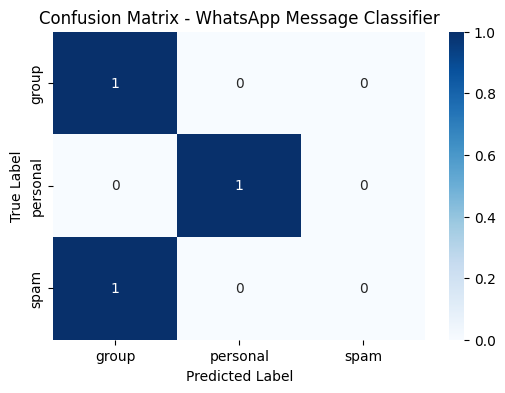

In [48]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=['group', 'personal', 'spam'], yticklabels=['group', 'personal', 'spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - WhatsApp Message Classifier')
plt.show()

---

# Task 5.
Use ChatGPT or Copilot to generate Python code for a KNN-based image classifier that distinguishes between images of cricket bats and footballs (use any small sample image dataset or random pixel arrays), then run and test the code, noting any changes you made to get it working.<br><br><em><strong>Hint:</strong> Paste the AI-generated code, describe any errors, and how you fixed them.</em>

### AI Generated Code (Before Fix)

In [49]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

# Mocking 10 images of size 28x28 (cricket bats and footballs)
X_images = np.random.rand(10, 28, 28) 
y_labels = ['bat', 'football', 'bat', 'football', 'bat', 'football', 'bat', 'football', 'bat', 'football']

knn = KNeighborsClassifier(n_neighbors=3)
# ERROR happens here:
knn.fit(X_images, y_labels)

ValueError: Found array with dim 3, while dim <= 2 is required by KNeighborsClassifier.

**Error encountered:** `ValueError: Found array with dim 3, while dim <= 2 is required by KNeighborsClassifier.`  
**How I fixed it:** Scikit-learn's machine learning models expect a 2D array of shape `(n_samples, n_features)`. The generated image data was 3D `(10, 28, 28)`. I fixed it by flattening the images using `.reshape(10, 28*28)` to convert each 2D image matrix into a 1D feature array before passing it to the KNN model.

In [50]:
# Fixed Working Code
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

np.random.seed(42)

X_images = np.random.rand(10, 28, 28)
y_labels = ['bat', 'football', 'bat', 'football', 'bat', 'football', 'bat', 'football', 'bat', 'football']

X_flattened = X_images.reshape(10, -1)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_flattened, y_labels)

new_image = np.random.rand(1, 28, 28)
new_flattened = new_image.reshape(1, -1)
prediction = knn.predict(new_flattened)

print(f"Prediction for new image: {prediction[0]}")

Prediction for new image: football
